In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np


flag = "patch_softmax"  # Change this to "patch_sigmoid_norm" or "patch_sigmoid_raw" as needed

if flag == "patch_sigmoid_norm":
    import yolo_patch_sigmoid_norm as _
elif flag == "patch_softmax":
    import yolo_patch_softmax as _
elif flag == "patch_sigmoid_raw":
    import yolo_patch_sigmoid_raw as _

# Load the YOLO model
yolo_model = YOLO("yolo11x.pt", task="detect")

# Image path
image_path = "photo.jpg"


 Image 0 - 9 detections
   
Detection 1:
   Box: [310.2603454589844, 149.7818603515625, 467.1591491699219, 240.27935791015625]
   Class: 57
   Conf: 0.9683
   Probability: [0.0006775356596335769, 2.68846852122806e-05, 0.0007585507119074464, 0.0006423266604542732, 0.0002087888278765604, 0.0008195348200388253, 0.0007783278706483543, 0.00017130727064795792, 0.00027288415003567934, 0.0003558644384611398, 0.00012560005416162312, 3.388232289580628e-05, 5.889754538657144e-05, 0.0018771087052300572, 2.4765160560491495e-05, 0.00019166157289873809, 0.00026374158915132284, 0.00042875221697613597, 5.875740316696465e-05, 0.00034345168387517333, 0.0006986276712268591, 0.0008363373344764113, 9.962159674614668e-05, 5.967120159766637e-05, 0.00017704881611280143, 0.00011745111260097474, 0.00016125982801895589, 0.00015098073345143348, 0.0006350527983158827, 6.26461478532292e-05, 8.339582564076409e-06, 0.0005680702743120492, 0.00024661002680659294, 0.00014337383618112653, 0.00022958492627367377, 0.000177

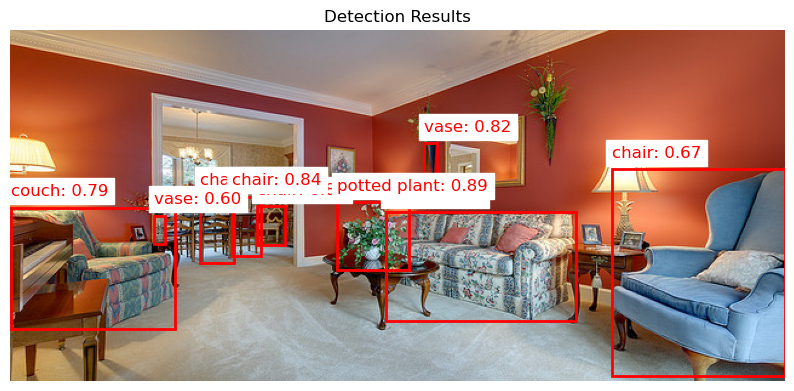

In [2]:
# Run prediction
results = yolo_model.predict(source=image_path, device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)

# Loop over detections in the image
for i, r in enumerate(results):
    print(f"\n Image {i} - {len(r.boxes)} detections")

    # Plot the image and overlay bounding boxes
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    for j in range(len(r.boxes)):
        box = r.boxes.xyxy[j].tolist()
        cls = int(r.boxes.cls[j].item())
        conf = float(r.boxes.conf[j].item())
        probs = r.boxes.probs[j].tolist()

        print(f"   \nDetection {j+1}:")
        print(f"   Box: {box}")
        print(f"   Class: {cls}")
        print(f"   Conf: {conf:.4f}")
        print(f"   Probability: {probs}") 
              
        names = yolo_model.names  # Get class names
        x1, y1, x2, y2 = box
        label = f"{names[cls]}: {conf:.2f}"
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', linewidth=2, fill=False))
        plt.text(x1, y1 - 10, label, color='red', fontsize=12, backgroundcolor='white')

    plt.axis('off')
    plt.title("Detection Results")
    plt.show()

In [ ]:
def sigmoid(x):
    """Compute the sigmoid function."""
    return 1 / (1 + np.exp(-x))
x = 2.3514
y = sigmoid(x)
print(f"Sigmoid({x}) = {y:.4f}")

Sigmoid(2.3514) = 0.9130


In [3]:
def parse_detection_results(results):
    """
    Extract detection outputs from YOLO-like model results.

    Args:
        results: List of detection results for ONE IMAGE (e.g., from Ultralytics YOLOv8).

    Returns:
        tuple: (xyxy, conf, cls, prob_vectors, names)
            - xyxy: ndarray of shape (N, 4), bounding boxes in [x1, y1, x2, y2] format
            - conf: ndarray of shape (N,), confidence scores
            - cls: ndarray of shape (N,), class IDs
            - prob_vectors: ndarray of shape (N, num_classes), per-class probabilities
            - names: list or dict of class names
            - num_detections: int, number of detections
    """
    result = results[0]  # One image, one result

    xyxy = result.boxes.xyxy.cpu().numpy()         # (N, 4)
    conf = result.boxes.conf.cpu().numpy()         # (N,)
    cls = result.boxes.cls.cpu().numpy()           # (N,)
    prob_vectors = result.boxes.probs.cpu().numpy()  # (N, num_classes)
    names = result.names                           # class names
    num_detections = len(xyxy)                    # number of detections

    return xyxy, conf, cls, prob_vectors, names, num_detections


In [4]:
results = yolo_model.predict(source=image_path, device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
xyxy, conf, cls, prob_vectors, names, num_detections = parse_detection_results(results)

print(f"Number of detections: {num_detections}")
print(f"Bounding boxes (xyxy): {xyxy}")
print(f"Confidence scores: {conf}")
print(f"Class IDs: {cls}")
print(f"Probability vectors: {prob_vectors}")
print(f"Class names: {names}")

Number of detections: 9
Bounding boxes (xyxy): [[     310.26      149.78      467.16      240.28]
 [   0.033295       146.5      135.85      246.97]
 [     156.48      137.21      184.31      191.87]
 [      496.4      114.82       639.7      285.15]
 [     203.61      145.27      226.65      177.02]
 [      269.9      141.97      329.23      197.87]
 [     182.98      137.29      207.07      186.39]
 [     341.67       93.08      351.78      121.75]
 [     118.76      153.09      127.68      175.98]]
Confidence scores: [[     0.9683]
 [    0.79483]
 [     0.9452]
 [    0.67062]
 [    0.88164]
 [    0.88538]
 [    0.84213]
 [    0.82154]
 [    0.60244]]
Class IDs: [57 57 56 56 56 58 56 75 75]
Probability vectors: [[ 0.00067754  2.6885e-05  0.00075855  0.00064233  0.00020879  0.00081953  0.00077833  0.00017131  0.00027288  0.00035586   0.0001256  3.3882e-05  5.8898e-05   0.0018771  2.4765e-05  0.00019166  0.00026374  0.00042875  5.8757e-05  0.00034345  0.00069863  0.00083634  9.9622e-05